This Is Part 1 Of The Data Analysis Project Which Requires Cleaning All Of The Dataset.

# Loading The Data:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data
df = pd.read_csv('Datasets/Dataset.csv')

# 2. Print first 5 rows
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


# Checking The Dataset's Shape And The Data Types It Has:

In [3]:
print(f"Total Rows: {df.shape[0]}") # Print total number of rows
print(f"Total Columns: {df.shape[1]}") # Print total number of columns
print(f"Data Type: {df.info()}") # Print data types of each column

Total Rows: 2930
Total Columns: 82
<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str

# Fixing Some Of The Columns:

In [4]:
# Fix the ID column cuz it's not a feature, it's a label
if 'PID' in df.columns:
    df = df.set_index('PID')

# Fix the Subclass Numbers that are ACTUALLY Categories
df['MS SubClass'] = df['MS SubClass'].astype(str)

# 3. Fix the Month Sold It's a cycle, not a growing number.
df['Mo Sold'] = df['Mo Sold'].astype(str)

print("Dtypes Fixed.")

Dtypes Fixed.


# Getting Info About Messing Values And What Columns Should Be Removed In The Dataset:

In [5]:
# Calculate total missing values per column
missing_data = df.isnull().sum()

# Only show columns that actually have missing values
print(missing_data[missing_data > 0].sort_values(ascending=False))

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Cond        159
Garage Yr Blt      159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
Bsmt Qual           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
BsmtFin SF 1         1
BsmtFin SF 2         1
Electrical           1
Total Bsmt SF        1
Bsmt Unf SF          1
Garage Area          1
Garage Cars          1
dtype: int64


In [ ]:
# Fill Nulls With The Median
# I Use Median Because It's Not Affected By Outliers.
if 'Lot Frontage' in df.columns:
    df['Lot Frontage'] = df['Lot Frontage'].fillna(df['Lot Frontage'].median())

# Fill Categorical Nulls with 'None'
# This tells the anyone who see this that a house doesn't have a basement/garage in the first place, instead of just being missing data.
cat_cols_with_nulls = ['Pool QC', 'Misc Feature', 'Alley', 'Fence', 
                       'Fireplace Qu', 'Garage Type', 'Garage Finish', 
                       'Garage Qual', 'Garage Cond', 'Bsmt Qual', 
                       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 
                       'BsmtFin Type 2', 'Mas Vnr Type']

for col in cat_cols_with_nulls:
    if col in df.columns:
        df[col] = df[col].fillna('None')

        # List of columns where nulls should be filled with 0
zero_fill_cols = [
    'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 
    'Total Bsmt SF', 'Bsmt Full Bath', 'Bsmt Half Bath', 
    'Garage Cars', 'Garage Area']

# Fill them with 0
for col in zero_fill_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Since every house has electricity, we fill the 1 missing value with the most common type
if 'Electrical' in df.columns:
    df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

# Special Case: Garage Yr Blt
# If there is no garage, we can't have a year so we set this to the Year the house was built.
if 'Garage Yr Blt' in df.columns:
    df['Garage Yr Blt'] = df['Garage Yr Blt'].fillna(df['Year Built'])

print("Numerical nulls handled!")
print(df[zero_fill_cols + ['Electrical', 'Garage Yr Blt']].isnull().sum())

# Final Check: See if any nulls remain
remaining_nulls = df.isnull().sum()
print(remaining_nulls[remaining_nulls > 0])

Numerical nulls handled!
Mas Vnr Area      0
BsmtFin SF 1      0
BsmtFin SF 2      0
Bsmt Unf SF       0
Total Bsmt SF     0
Bsmt Full Bath    0
Bsmt Half Bath    0
Garage Cars       0
Garage Area       0
Electrical        0
Garage Yr Blt     0
dtype: int64
Series([], dtype: int64)


# Handling Duplicates:

In [7]:
# Check Duplicate Rows
print(f"Duplicate rows found: {df.duplicated().sum()}")

# Remove them (if any exist)
df = df.drop_duplicates()

Duplicate rows found: 0


# Spotting Outliers:

99th Percentile Cutoff: $456,666.37
Rows remaining: 2897


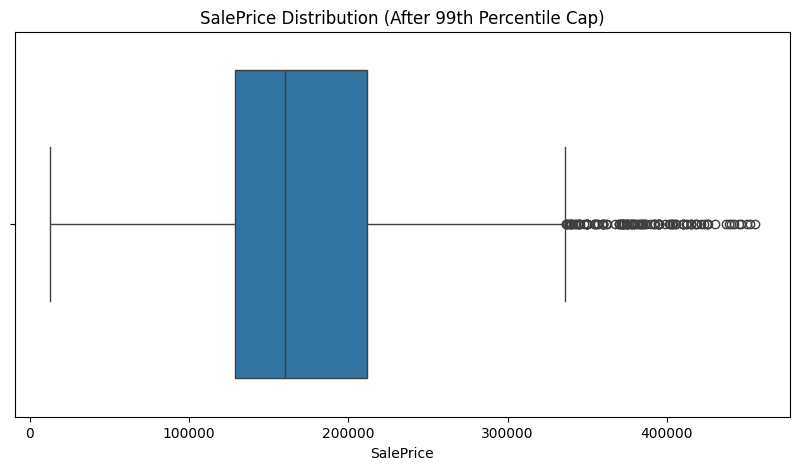

In [ ]:
# 1. Check if we have already filtered (to prevent the shrinking loop)
if len(df) > 2900: 
    # Calculate the limit based on the FRESH data only
    price_limit = df['SalePrice'].quantile(0.99)
    print(f"99th Percentile Cutoff: ${price_limit:,.2f}")

    # This keeps houses under the price limit AND under 4000 sq ft
    df = df[(df['SalePrice'] <= price_limit) & (df['Gr Liv Area'] < 4000)]
    
    print(f"Rows remaining: {len(df)}")
else:
    print(f"Data already filtered. Current row count: {len(df)}")
    print("To filter again, please re-run the 'Load Data' cell at the top.")

# 2. Visualize
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['SalePrice'])
plt.title('SalePrice Distribution (After 99th Percentile Cap)')
plt.show()

# Writing A Function That Does The Whole Thing And The Three Step Check:

In [ ]:
def clean_housing_data(df_input):
# Create a copy so we don't overwrite the original variable
    new_df = df_input.copy()
    
# Set Index and Fix Dtypes
    if 'PID' in new_df.columns:
        new_df.set_index('PID', inplace=True)
    new_df['MS SubClass'] = new_df['MS SubClass'].astype(str)
    new_df['Mo Sold'] = new_df['Mo Sold'].astype(str)

# Fill Nulls
    cat_cols = ['Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Mas Vnr Type']
    for col in cat_cols:
        if col in new_df.columns:
            new_df[col] = new_df[col].fillna('None')

    new_df['Lot Frontage'] = new_df['Lot Frontage'].fillna(new_df['Lot Frontage'].median())
    
    zero_cols = ['Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Garage Cars', 'Garage Area']
    for col in zero_cols:
        if col in new_df.columns:
            new_df[col] = new_df[col].fillna(0)

# Apply Outlier Caps
    price_limit = new_df['SalePrice'].quantile(0.99)
    new_df = new_df[(new_df['SalePrice'] <= price_limit) & (new_df['Gr Liv Area'] < 4000)]
    
    return new_df

df_final = clean_housing_data(pd.read_csv('Datasets/Dataset.csv'))
print(f"Final Data Cleaned! Total: {len(df_final)}")

Final Data Cleaned! Total: 2897


# Creating A New CSV File For The Cleaned Dataset:

In [ ]:
# Save the cleaned dataframe to a new file
df_final.to_csv('Datasets/Dataset_Cleaned.csv', index=True)

print("Cleaned data saved successfully!")

Cleaned data saved successfully!


# Checking The Missing Values:

In [11]:
# Final Checks
print(f"Null count: {df.isnull().sum().sum()}") # Should be 0
print(f"Duplicate count: {df.duplicated().sum()}") # Should be 0
print(f"Final shape: {df.shape}")

Null count: 0
Duplicate count: 0
Final shape: (2897, 81)
